In [1]:
import matplotlib.pyplot as plt
import numpy as np
import skimage
import utils


In [2]:
import numpy as np
import matplotlib.pyplot as plt

def convolve_im_spatial(im: np.array, kernel: np.array, verbose=True):
    """Convolves the image (im) with the spatial kernel (kernel),
       and returns the resulting image.

       "verbose" can be used for turning on/off visualization.

       Args:
           im: np.array of shape [H, W]
           kernel: np.array of shape [K, K] 
           verbose: bool
       Returns:
           im: np.array of shape [H, W]
    """
    
    # Compute FFT of the image
    fft_im = np.fft.fft2(im)
    fft_im_shifted = np.fft.fftshift(fft_im)  # Shift for visualization
    
    # Pad kernel to match image size
    pad_kernel = np.pad(kernel, (
        (0, im.shape[0] - kernel.shape[0]), 
        (0, im.shape[1] - kernel.shape[1])
    ), 'constant')
    
    # Compute FFT of the padded kernel
    fft_kernel = np.fft.fft2(pad_kernel)
    fft_kernel_shifted = np.fft.fftshift(fft_kernel)  # Shift for visualization

    # Multiply FFT of image with FFT of kernel
    fft_filtered = fft_im * fft_kernel
    
    # Inverse FFT to get the spatial domain filtered image
    filtered_im = np.fft.ifft2(fft_filtered).real  # Only take real part

    # Visualization
    if verbose:
        plt.figure(figsize=(20, 4))
        
        # Original Image
        plt.subplot(1, 5, 1)
        plt.imshow(im, cmap="gray")
        plt.title("Original Image")
        
        # Amplitude of Image in Frequency Domain
        plt.subplot(1, 5, 2)
        plt.imshow(np.log(1 + np.abs(fft_im_shifted)), cmap="gray")
        plt.title("Amplitude of FFT Image")
        
        # Amplitude of Kernel in Frequency Domain
        plt.subplot(1, 5, 3)
        plt.imshow(np.log(1 + np.abs(fft_kernel_shifted)), cmap="gray")
        plt.title("Amplitude of FFT Kernel")
        
        # Amplitude of Filtered Image in Frequency Domain
        plt.subplot(1, 5, 4)
        fft_filtered_shifted = np.fft.fftshift(fft_filtered)
        plt.imshow(np.log(1 + np.abs(fft_filtered_shifted)), cmap="gray")
        plt.title("Amplitude of Filtered FFT Image")
        
        # Filtered Image in Spatial Domain
        plt.subplot(1, 5, 5)
        plt.imshow(filtered_im, cmap="gray")
        plt.title("Filtered Spatial Image")
        
        plt.show()

    return filtered_im

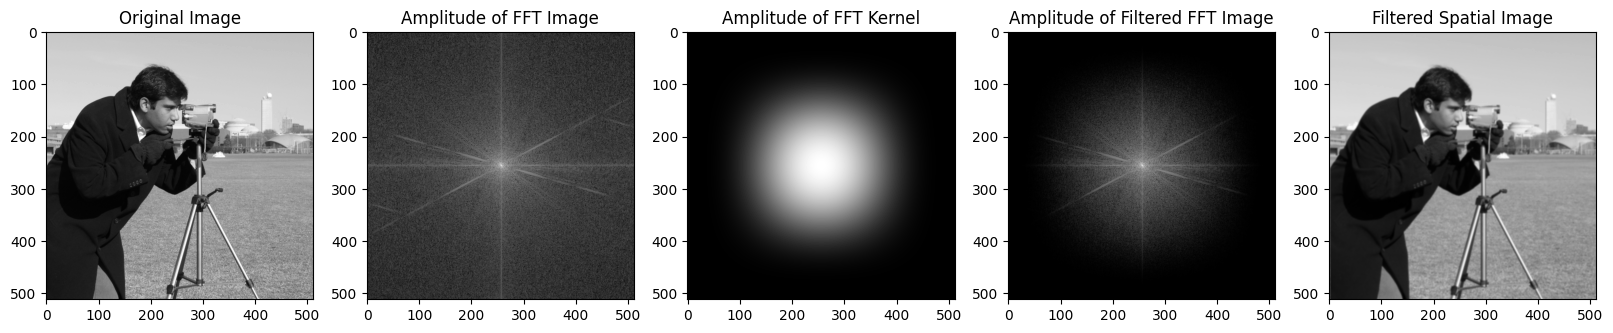

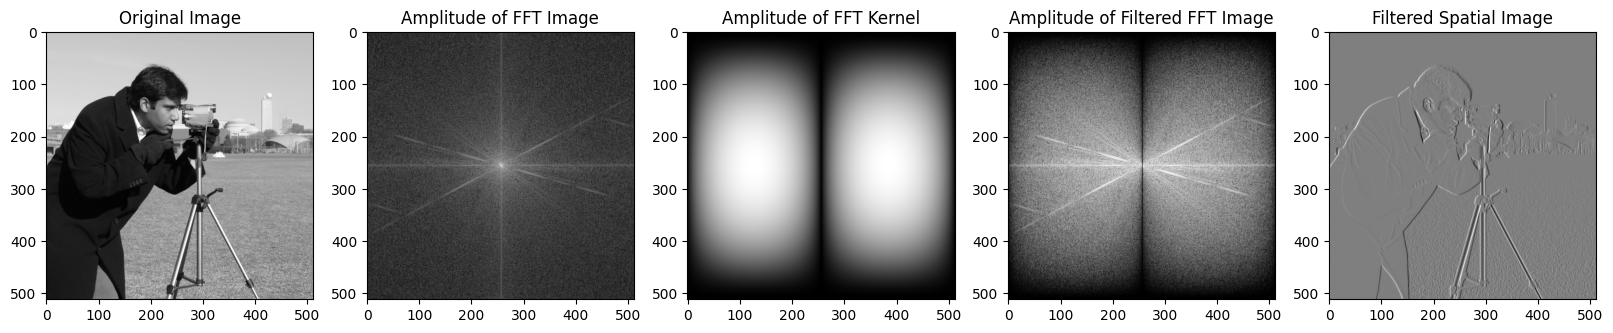

Saving image to: image_processed/camera_gaussian.png
Saving image to: image_processed/camera_sobelx.png


/Users/michaelbrusegard/Developer/visual-computing-fundamentals/image-processing-2/utils.py:27: UserWarning: Image min/max is outside the range [0.0, 1.0]. Squashing the image to this range. (Can be safely ignored)
  warnings.warn("Image min/max is outside the range [0.0, 1.0]. Squashing the image to this range. (Can be safely ignored)")


In [3]:
if __name__ == "__main__":
    verbose = True  # change if you want

    # Changing this code should not be needed
    im = skimage.data.camera()
    im = utils.uint8_to_float(im)

    # DO NOT CHANGE
    gaussian_kernel = np.array([
        [1, 4, 6, 4, 1],
        [4, 16, 24, 16, 4],
        [6, 24, 36, 24, 6],
        [4, 16, 24, 16, 4],
        [1, 4, 6, 4, 1],
    ]) / 256
    image_gaussian = convolve_im_spatial(im, gaussian_kernel, verbose)

    # DO NOT CHANGE
    sobel_horizontal = np.array([
        [-1, 0, 1],
        [-2, 0, 2],
        [-1, 0, 1]
    ])
    image_sobelx = convolve_im_spatial(im, sobel_horizontal, verbose)

    if verbose:
        plt.show()

    utils.save_im("camera_gaussian.png", image_gaussian)
    utils.save_im("camera_sobelx.png", image_sobelx)